In [106]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from IPython.display import display
import ipywidgets as widgets

In [ ]:
# Collapsible output panel for import/setup logs
import_messages_out = widgets.Output(
    layout=widgets.Layout(max_height="220px", overflow_y="auto")
)
import_messages_widget = widgets.Accordion(children=[import_messages_out])
import_messages_widget.set_title(0, "Import and Setup Messages")
import_messages_widget.selected_index = None

def log_import_message(message: str) -> None:
    """Route setup/import logs to the collapsible message panel."""
    with import_messages_out:
        print(message)



In [ ]:
display(import_messages_widget)


In [ ]:
import os
import subprocess
import sys

INSTALL_PACKAGE = False  # Set to True to always install, False to skip installation
# INSTALL_PACKAGE = os.getenv("INSTALL_PACKAGE", "0").strip().lower() in {
#     "1",
#     "true",
#     "yes",
# }

# Check if we're in Voila (where napari can't work anyway)
IS_VOILA = 'voila' in sys.modules or os.getenv('JUPYTER_PLATFORM_DIRS') is not None

# Use collapsible widget logger when available
log_fn = globals().get("log_import_message", print)

# Always install in regular Jupyter (napari needs the package)
# Skip in Voila (napari won't work there anyway)
if not IS_VOILA and INSTALL_PACKAGE:
    log_fn("Installing package in editable mode for napari support...")
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', '..'], check=False)
    log_fn("Installation complete.")
else:
    log_fn("Running in Voila - package installation skipped (napari unavailable in this context)")


Running in Voila - package installation skipped (napari unavailable in this context)


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from skimage import measure, filters
import tifffile as tiff
import sys
import traceback
import os


def add_module_to_path() -> None:
    # Determine the threshold_activity_classifier directory.
    current = Path(os.getcwd())
    src = None

    while current != current.parent:
        if (current / 'utils').exists() and (current / 'core').exists() and (current / 'notebooks').exists():
            src = current
            break
        current = current.parent

    if src is None:
        src = Path(os.getcwd()).parent
        if not ((src / 'utils').exists() and (src / 'core').exists()):
            src = Path(os.getcwd()).parent.parent

    log_fn = globals().get("log_import_message", print)
    log_fn(f"SRC path: {src}")
    log_fn(f"CWD: {Path.cwd()}")
    log_fn(f"utils exists: {(src / 'utils').exists()}")
    log_fn(f"core exists: {(src / 'core').exists()}")

    sys.path.insert(0, str(src))
    sys.path.insert(0, str(Path(src).parent))

    log_fn("sys.path updated successfully")
    log_fn(f"Python path entries: {sys.path[:3]}")


try:
    import threshold_activity_classifier
except ImportError:
    add_module_to_path()




In [ ]:
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

from glob import glob


In [108]:
from threshold_activity_classifier.utils.io import find_label_from_mcherry_path, find_brightfield_from_mcherry_path, find_activity_from_mcherry_path, get_images_from_mcherry
from threshold_activity_classifier.core.classifier import create_activity_labeled_image
from threshold_activity_classifier.ui import NapariImageViewer, visualize_sample_zstack_napari


In [ ]:
# Event handlers for directory selection and data preparation

import shutil
import re

try:
    from src.utils.file_utils import list_all_files, rename_all_files, copy_without_split_dict, ConfigurableFileHandler
except ImportError:
    from threshold_activity_classifier.utils.file_utils import list_all_files, rename_all_files, copy_without_split_dict, ConfigurableFileHandler



In [109]:

"""Checks if the current notebook is running in Voilà."""
IS_VOILA =  os.environ.get('SERVER_SOFTWARE', '').startswith('voila')

if IS_VOILA:
    print("Running in Voilà!")
else:
    print("Running in Jupyter (or another environment)")


Running in Jupyter (or another environment)


# Cell Activity Classification Based on Wavelength 2 Intensity

In [89]:
workflow_accordion = widgets.Accordion(children=[
    widgets.HTML(value="""
    <div style='max-width:900px; padding:10px; font-family: sans-serif;'>
    <p>This notebook classifies cell instance segmentation labels as <b>active</b> or <b>dead</b> cells 
    based on intensity values from wavelength 2 images.</p>
    <h3>Workflow:</h3>
    <ol>
        <li>Choose directory containing control and sample images</li>
        <li>Set parameters in the configuration cell</li>
        <li>Run all cells to process images and generate results</li>
        <li>Review classification plots and statistics</li>
        <li>Exported results include per-instance data, image summaries, and overall statistics</li>
    </ol>
    </div>
    """)
])
workflow_accordion.set_title(0, 'Cell Activity Classification - Overview & Workflow')
workflow_accordion.selected_index = None  # collapsed by default



In [90]:
## Input directory selection widgets
if not IS_VOILA:
    display(workflow_accordion)

Accordion(children=(HTML(value="\n    <div style='max-width:900px; padding:10px; font-family: sans-serif;'>\n …

In [91]:
# Parameters - edit as needed
data_root = Path("../../../data")

# Default directories for each data type
RAW_DIR = data_root / "Plate 2426"
PREPROCESSED_DIR = data_root / "Plate 2426_new_preprocessed_2D_split"
SPLIT_DIR = data_root / "Plate 2426_new_preprocessed_2D_split/subset"

# Current working directories (will be set by widgets)
input_dir = SPLIT_DIR
output_dir = data_root / "Plate 2426_new_preprocessed_2D_split/activity"

# File patterns
brightfield_pattern = "*_BF.tif"   # pattern for brightfield images (default : wavelength 1)
mcherry_pattern = "*_mCherry.tif"   # pattern for mCherry images (default : wavelength 2)
label_suffix = "_Cells.tif"  # expected suffix for instance labels

# Negative control sample IDs (for splitting)
NEGATIVE_CONTROL_IDS = ["A01", "A02", "H11", "H12"]  # adjust based on plate layout



In [92]:
def display_widgets(widget_list):
    """Helper function to display a list of widgets in a vertical layout."""
    for widget in widget_list:
        widget.layout.visibility = "visible"

def hide_widgets(widget_list):
    """Helper function to hide a list of widgets."""
    for widget in widget_list:
        widget.layout.visibility = "hidden"

def enable_widget(w):
    w.layout.display = ""      # restore default widget display (best)
    # or: w.layout.display = "flex"

def disable_widget(w):
    w.layout.display = "none"

In [93]:
# Discovery functions for raw and preprocessed files
import re

def discover_raw_metadata(raw_dir: Path) -> tuple:
    """Discover available time points, samples, and plates from raw directory.
    
    Returns:
        Tuple of (time_points, sample_ids, plate_numbers) as sorted lists
    """
    raw_path = Path(raw_dir).expanduser()
    if not raw_path.exists():
        return [], [], []
    
    time_points = set()
    sample_ids = set()
    plate_numbers = set()
    
    # Find all TIFF files
    all_files = list(raw_path.rglob("*.tif")) + list(raw_path.rglob("*.tiff"))
    
    for file_path in all_files:
        # Extract plate number from directory path
        plate_match = re.search(r'Plate\s*(\d+)', str(file_path))
        if plate_match:
            plate_numbers.add(f"Plate {plate_match.group(1)}")
        
        # Extract sample ID (e.g., A01, B02)
        sample_match = re.search(r'([A-Z]\d+)', file_path.name)
        if sample_match:
            sample_ids.add(sample_match.group(1))
        
        # Extract time point
        time_match = re.search(r't(\d+)_', file_path.name)
        if time_match:
            time_points.add(f"t{time_match.group(1)}")
    
    return sorted(time_points), sorted(sample_ids), sorted(plate_numbers)


def discover_preprocessed_samples(prep_dir: Path) -> tuple:
    """Discover available samples and plates from preprocessed directory.
    
    Returns:
        Tuple of (sample_ids, plate_numbers) as sorted lists
    """
    prep_path = Path(prep_dir).expanduser()
    if not prep_path.exists():
        return [], []
    
    sample_ids = set()
    plate_numbers = set()
    
    # Find all TIFF files
    all_files = list(prep_path.rglob("*.tif")) + list(prep_path.rglob("*.tiff"))
    
    for file_path in all_files:
        # Extract plate number (e.g., p2126 or Plate 2126)
        plate_match = re.search(r'p(\d+)|Plate\s*(\d+)', file_path.name)
        if plate_match:
            plate_num = plate_match.group(1) or plate_match.group(2)
            plate_numbers.add(f"p{plate_num}")
        
        # Extract sample ID
        sample_match = re.search(r'([A-Z]\d+)', file_path.name)
        if sample_match:
            sample_ids.add(sample_match.group(1))
    
    return sorted(sample_ids), sorted(plate_numbers)


In [94]:
# Data type selector and directory widgets

# Data type options
data_type_selector = widgets.RadioButtons(
    options=[
        ('Raw files (requires preprocessing)', 'raw'),
        ('Preprocessed files (requires splitting)', 'preprocessed'),
        ('Split files (ready for analysis)', 'split')
    ],
    value='split',
    layout=widgets.Layout(width='400px'),
    style={'description_width': '100px'}
)

# ===== RAW FILES WIDGETS =====
raw_input_dir = widgets.Text(
    value=str(RAW_DIR),
    description='Raw dir:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='800px', display='none')
)

discover_raw_btn = widgets.Button(
    description='Discover raw files',
    button_style='info',
    icon='search',
    layout=widgets.Layout(width='200px', display='none')
)
discover_raw_out = widgets.Output()

# ===== WAVELENGTH CONFIGURATION WIDGETS (NEW) =====
wavelength_w1 = widgets.Text(
    value='BF',
    description='w1 → ',
    placeholder='e.g., BF',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='200px', display='none')
)

wavelength_w2 = widgets.Text(
    value='mCherry',
    description='w2 → ',
    placeholder='e.g., mCherry',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='200px', display='none')
)

wavelength_w3 = widgets.Text(
    value='AnnexinV',
    description='w3 → ',
    placeholder='e.g., AnnexinV',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='200px', display='none')
)

plate_number_input = widgets.Text(
    value='',
    description='Plate #:',
    placeholder='e.g., 2126 (auto-detected if empty)',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='300px', display='none')
)

# Multi-select widgets for raw files
raw_time_points_select = widgets.Text(
    value='',
    description='Time points:',
    placeholder='e.g., t0,t1,t2',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='400px', display='none')
)

raw_samples_select = widgets.Text(
    value='',
    description='Samples (IDs):',
    placeholder='e.g., A01,B02,C03',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='400px', display='none')
)

raw_preprocess_output = widgets.Text(
    value=str(PREPROCESSED_DIR),
    description='Output to:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='800px', display='none')
)

raw_preprocess_btn = widgets.Button(
    description='Preprocess selected files',
    button_style='warning',
    icon='cogs',
    layout=widgets.Layout(width='220px', display='none')
)
raw_preprocess_out = widgets.Output()

raw_file_widgets = [
    # Raw files section
    widgets.HTML(value="<h3>Raw Files (Stage 1: Preprocessing)</h3>"),
    raw_input_dir,
    discover_raw_btn,
    discover_raw_out,
    widgets.HTML(value="<b>Channel Mappings (wavelengths):</b>"),
    wavelength_w1, wavelength_w2, wavelength_w3,
    plate_number_input,
    widgets.HTML(value="<b>Select metadata to filter by:</b>"),
    raw_time_points_select,
    raw_samples_select,
    raw_preprocess_output,
    raw_preprocess_btn,
    raw_preprocess_out,
]


# ===== PREPROCESSED FILES WIDGETS =====
prep_input_dir = widgets.Text(
    value=str(PREPROCESSED_DIR),
    description='Preprocessed dir:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='800px', display='none')
)

discover_prep_btn = widgets.Button(
    description='Discover preprocessed files',
    button_style='info',
    icon='search',
    layout=widgets.Layout(width='230px', display='none')
)
discover_prep_out = widgets.Output()

# Multi-select widgets for preprocessed files

neg_controls_select = widgets.Text(
    value='',
    description='Negative controls:',
    placeholder='e.g., A01,B02,H12',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='500px', display='none')
)

sample_samples_select = widgets.Text(
    value='',
    description='Sample cells:',
    placeholder='e.g., A03,B04,C05',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='500px', display='none')
)

prep_split_output = widgets.Text(
    value=str(SPLIT_DIR),
    description='Split to:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='800px', display='none')
)

prep_split_btn = widgets.Button(
    description='Split selected files',
    button_style='warning',
    icon='code-branch',
    layout=widgets.Layout(width='200px', display='none')
)
prep_split_out = widgets.Output()

prep_split_widgets = [
    # Preprocessed files section
    widgets.HTML(value="<h3>Preprocessed Files (Stage 2: Splitting)</h3>"),
    prep_input_dir,
    discover_prep_btn,
    discover_prep_out,
    widgets.HTML(value="<b>Negative controls (comma-separated):</b>"),
    neg_controls_select,
    widgets.HTML(value="<b>Sample cells (comma-separated):</b>"),
    sample_samples_select,
    prep_split_output,
    prep_split_btn,
    prep_split_out,
]

# ===== SPLIT FILES WIDGETS =====
neg_control_dir = widgets.Text(
    value=str(SPLIT_DIR / 'negative_controls'),
    description='Neg. control dir:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='800px')
)

set_neg_control_btn = widgets.Button(
    description='Set negative control directory',
    button_style='info',
    layout=widgets.Layout(width='240px')
)

neg_control_out = widgets.Output()

neg_control_widgets = [
    widgets.HTML(value="<h3>Negative Controls (Stage 3: Analysis)</h3>"),    
    neg_control_dir, set_neg_control_btn, neg_control_out]

In [95]:

def update_ui_for_data_type(change):
    """Update visible widgets based on selected data type."""
    data_type = change['new'] if change else data_type_selector.value
    
    # Hide all stage-specific widgets
    for w in raw_file_widgets + prep_split_widgets + neg_control_widgets:
        w.layout.display = 'none'
    
    if data_type == 'raw':
        # Show raw files widgets
        for w in raw_file_widgets:
            w.layout.display = ''
    elif data_type == 'preprocessed':
        # Show preprocessed files widgets
        for w in prep_split_widgets:
            w.layout.display = ''
    else:
        # Show split files widgets (only negative control directory selection)
        for w in neg_control_widgets:
            w.layout.display = ''


data_type_selector.observe(update_ui_for_data_type, names='value')

# Assemble directory widgets
dir_widgets = [
    widgets.HTML(value="<h1>Directory Selection & Data Filtering</h1>"),
    widgets.HTML(value="<p>Select the type of data you want to process:</p>"),
    data_type_selector,
] + raw_file_widgets + prep_split_widgets + neg_control_widgets

# Hide all stage-specific widgets
for w in raw_file_widgets + prep_split_widgets + neg_control_widgets:
    w.layout.display = 'none'


In [ ]:

def get_configured_file_handler():
    from threshold_activity_classifier.utils.file_utils import ConfigurableFileHandler
    """Create ConfigurableFileHandler with user-provided wavelength mappings and plate number."""
    # Build wavelength mappings from widget inputs
    wavelength_mappings = {}
    
    w1_val = wavelength_w1.value.strip()
    if w1_val:
        wavelength_mappings[1] = w1_val
    
    w2_val = wavelength_w2.value.strip()
    if w2_val:
        wavelength_mappings[2] = w2_val
    
    w3_val = wavelength_w3.value.strip()
    if w3_val:
        wavelength_mappings[3] = w3_val
    
    # Get plate number if provided
    plate_num = plate_number_input.value.strip() if plate_number_input.value.strip() else None
    
    # Create handler with user configuration
    if wavelength_mappings:
        handler = ConfigurableFileHandler(
            wavelength_mappings=wavelength_mappings,
            plate_number=plate_num
        )
    else:
        # Use default ConfigurableFileHandler (loads from YAML)
        handler = ConfigurableFileHandler(plate_number=plate_num)
    
    return handler

def on_discover_raw(btn):
    """Discover available time points, samples, and plates from raw directory."""
    with discover_raw_out:
        discover_raw_out.clear_output()
        raw_path = Path(raw_input_dir.value).expanduser()
        
        if not raw_path.exists():
            print(f"Error: Raw directory does not exist: {raw_path}")
            return
        
        print(f"Discovering files in: {raw_path}")
        time_points, samples, plates = discover_raw_metadata(raw_path)
        
        print(f"Found {len(time_points)} time points: {time_points}")
        print(f"Found {len(samples)} samples: {samples}")
        print(f"Found {len(plates)} plates: {plates}")
                
        # print(f"\nAll items pre-selected. Deselect to exclude specific items.")


def on_preprocess_raw(btn):
    """Preprocess selected raw files by copying/renaming to standardized format."""
    with raw_preprocess_out:
        raw_preprocess_out.clear_output()
        raw_path = Path(raw_input_dir.value).expanduser()
        prep_path = Path(raw_preprocess_output.value).expanduser()
        
        if not raw_path.exists():
            print(f"Error: Raw directory does not exist: {raw_path}")
            return
        
        # Get configured handler with user wavelength mappings
        file_handler = globals().get('file_handler', None)
        assert file_handler is not None, "Error: File handler not configured. Please discover raw files first to set wavelength mappings."
        
        print("═" * 70)
        print("Raw File Preprocessing Configuration")
        print("═" * 70)
        print(f"Input directory:  {raw_path}")
        print(f"Output directory: {prep_path}")
        print(f"\nWavelength mappings:")
        for wl_idx, channel_name in sorted(file_handler.wavelength_mappings.items()):
            print(f"  w{wl_idx} → {channel_name}")
        if file_handler._default_plate_number:
            print(f"Default plate number: {file_handler._default_plate_number}")
        print("═" * 70)
        
        # Get selected filters
        selected_times = set(tp.strip() for tp in raw_time_points_select.value.split(',') if tp.strip())
        selected_samples = set(s.strip() for s in raw_samples_select.value.split(',') if s.strip())
        
        if not (selected_times or selected_samples):
            print("Error: Please select at least one time point or sample.")
            return
        
        prep_path.mkdir(parents=True, exist_ok=True)
        
        print(f"\nProcessing filters:")
        print(f"  Time points: {selected_times if selected_times else 'All'}")
        print(f"  Samples: {selected_samples if selected_samples else 'All'}")
        
        # Find and filter files
        all_files = list_all_files(str(raw_path), file_handler=file_handler)
        renamed_file_tuples = rename_all_files(all_files, file_handler)
        # all_files = list(raw_path.rglob("*.tif")) + list(raw_path.rglob("*.tiff"))
        filtered_files = {}

        for file_type in renamed_file_tuples:
            print(f"Found {len(renamed_file_tuples[file_type])} files of type '{file_type}'")
            filtered_files[file_type] = []

            for src, renamed in renamed_file_tuples[file_type]:

                # Check sample filter
                if selected_samples:
                    sample_match = re.search(r'([A-Z]\d+)', renamed)
                    if not sample_match or sample_match.group(1) not in selected_samples:
                        continue
                
                # Check time filter
                if selected_times:
                    time_match = re.search(r't(\d+)_', renamed)
                    if not time_match or f"t{time_match.group(1)}" not in selected_times:
                        continue
                
                filtered_files[file_type].append((src, renamed))
        
        if not filtered_files:
            print("No files match the selected criteria.")
            return
        
        print(f"\nProcessing {len(filtered_files)} files...")
        
        # Process files using the standard pipeline
        try:
            copied = copy_without_split_dict(filtered_files, prep_path)

        except Exception as e:
            print(f"Error during preprocessing: {str(e)}")
            traceback.print_exc()
            return
        
        print(f"\nPreprocessing complete. Processed {copied} files.")
        print(f"Preprocessed files saved to: {prep_path}")
        
        # Auto-transition to preprocessed stage
        prep_input_dir.value = str(prep_path)
        data_type_selector.value = 'preprocessed'


def on_discover_prep(btn):
    """Discover available samples and plates from preprocessed directory."""
    with discover_prep_out:
        discover_prep_out.clear_output()
        prep_path = Path(prep_input_dir.value).expanduser()
        
        if not prep_path.exists():
            print(f"Error: Preprocessed directory does not exist: {prep_path}")
            return
        
        print(f"Discovering files in: {prep_path}")
        samples, plates = discover_preprocessed_samples(prep_path)
        
        print(f"Found {len(samples)} samples: {samples}")
        print(f"Found {len(plates)} plates: {plates}")
                
        print(f"\nSelect samples to split. Check 'Negative controls' checkbox for control samples.")


def on_split_by_sample(btn):
    """Split preprocessed files into negative controls and samples."""
    file_handler = globals().get('file_handler', None)
    assert file_handler is not None, "Error: File handler not configured. Please preprocess raw files first to set wavelength mappings."

    with prep_split_out:
        prep_split_out.clear_output()
        prep_path = Path(prep_input_dir.value).expanduser()
        split_path = Path(prep_split_output.value).expanduser()
        
        if not prep_path.exists():
            print(f"Error: Preprocessed directory does not exist: {prep_path}")
            return
        
        # Parse comma-separated values from text inputs
        neg_ctrl_input = neg_controls_select.value.strip()
        samples_input = sample_samples_select.value.strip()
        
        # Parse into sets (case-insensitive, stripped)
        neg_controls = set(s.strip().upper() for s in neg_ctrl_input.split(',') if s.strip())
        samples = set(s.strip().upper() for s in samples_input.split(',') if s.strip())
        
        # Check if at least one is specified
        if not (neg_controls or samples):
            print("Error: Please specify at least one negative control or sample cell.")
            return
        
        print(f"Splitting files from: {prep_path}")
        print(f"Negative control samples: {neg_controls if neg_controls else 'None'}")
        print(f"Sample cells: {samples if samples else 'None'}")
        
        # Find all files and extract available sample IDs
        all_files = list(prep_path.rglob("*.tif")) + list(prep_path.rglob("*.tiff"))
        
        if not all_files:
            print("No TIFF files found in preprocessed directory.")
            return
        
        # Extract all available sample IDs from files
        available_samples = set()
        for file_path in all_files:
            sample_id = file_handler.extract_sample_id(file_path.name)
            if sample_id:
                available_samples.add(sample_id.upper())
        
        print(f"\nAvailable samples in directory: {sorted(available_samples)}")
        
        # Validate that specified samples exist
        invalid_neg_controls = neg_controls - available_samples
        invalid_samples = samples - available_samples
        
        if invalid_neg_controls:
            print(f"Warning: Negative control samples not found: {invalid_neg_controls}")
        
        if invalid_samples:
            print(f"Warning: Sample cells not found: {invalid_samples}")
        
        # Get the valid samples to process
        valid_neg_controls = neg_controls & available_samples
        valid_samples = samples & available_samples
        
        if not (valid_neg_controls or valid_samples):
            print("Error: None of the specified samples were found in the directory.")
            return
        
        print(f"\nProcessing:")
        print(f"  - Valid negative controls: {valid_neg_controls if valid_neg_controls else 'None'}")
        print(f"  - Valid sample cells: {valid_samples if valid_samples else 'None'}")
        
        # Create output directories
        controls_dir = split_path / "negative_controls"
        samples_dir = split_path / "samples"
        controls_dir.mkdir(parents=True, exist_ok=True)
        samples_dir.mkdir(parents=True, exist_ok=True)
        
        controls_count = 0
        samples_count = 0
        unmatched = 0
        
        for src_file in all_files:
            sample_id = file_handler.extract_sample_id(src_file.name)
            
            if sample_id is None:
                unmatched += 1
                continue
            
            sample_id_upper = sample_id.upper()
            
            # Determine destination based on selection
            if sample_id_upper in valid_neg_controls:
                dst_dir = controls_dir
                controls_count += 1
            elif sample_id_upper in valid_samples:
                dst_dir = samples_dir
                samples_count += 1
            else:
                continue  # Skip unselected samples
            
            # Copy file
            dst_file = dst_dir / src_file.name
            if not dst_file.exists():
                shutil.copy2(src_file, dst_file)
        
        print(f"\nSplit complete:")
        print(f"  - Negative controls: {controls_count} files -> {controls_dir}")
        print(f"  - Samples: {samples_count} files -> {samples_dir}")
        if unmatched > 0:
            print(f"  - Unmatched files (no sample ID): {unmatched}")
        
        # Auto-transition to split stage
        neg_control_dir.value = str(controls_dir)  # Set to negative controls directory
        data_type_selector.value = 'split'


def on_set_neg_control(btn):
    """Set negative control directory and enable analysis button."""
    with neg_control_out:
        neg_control_out.clear_output()
        in_path = Path(neg_control_dir.value).expanduser()
        
        if not in_path.exists():
            print(f"Error: Input directory does not exist: {in_path}")
            print(f"Error: Negative control directory does not exist: {in_path}")
            print(f"Available directories after split:")
            split_parent = in_path.parent
            if split_parent.exists():
                for item in split_parent.iterdir():
                    if item.is_dir():
                        print(f"  - {item.name}")
            return
        
        print(f"Negative control directory set: {in_path}")

        # Export to notebook globals
        globals()['input_dir'] = in_path
        
        global image_paths
        image_paths = sorted(glob(os.path.join(str(in_path), "**", mcherry_pattern), recursive=True))

        if not image_paths:
            print(f"Warning: No images found matching pattern '{mcherry_pattern}' under {in_path}")
            print("Check the input directory and image pattern.")
            return
        # Show sample filenames
        print(f"Found {len(image_paths)} images matching '{mcherry_pattern}'")
        
        if 'compute_stats_widgets' not in globals():
            print("Error: compute_stats_widgets not defined. Please run the cell that defines the analysis widgets.")
        else:
            compute_stats_widgets = globals()['compute_stats_widgets']
            display_widgets(compute_stats_widgets)



# Attach event handlers
discover_raw_btn.on_click(on_discover_raw)
raw_preprocess_btn.on_click(on_preprocess_raw)
discover_prep_btn.on_click(on_discover_prep)
prep_split_btn.on_click(on_split_by_sample)
set_neg_control_btn.on_click(on_set_neg_control)


In [ ]:
image_paths = None
file_handler = get_configured_file_handler()  # Initialize file handler with user configuration (or defaults)

In [97]:
if not IS_VOILA:
    display(widgets.VBox(dir_widgets))

In [78]:
# import threading
# Compute stats widgets
compute_stats_button = widgets.Button(description="Compute stats", button_style="primary")
# compute_stats_button.layout.visibility = "hidden"

compute_stats_out = widgets.Output()

# Outputs for the accordion panels
compute_stats_summary = widgets.Output(layout=widgets.Layout(border="1px solid #ddd", max_height="320px", overflow="auto"))
compute_stats_plot = widgets.Output()


# Accordion containing summary and plots
stats_accordion = widgets.Accordion(children=[compute_stats_summary, compute_stats_plot])
stats_accordion.set_title(0, "Per-image Summary")
stats_accordion.set_title(1, "Distribution Plots")
stats_accordion.selected_index = None  # collapsed by default

# Ensure the accordion is shown with the compute button
compute_stats_widgets = [
    widgets.HTML("<h1>Cell Activity Statistics</h1s>"),
    compute_stats_button, compute_stats_out, stats_accordion]

# # Trigger population shortly after compute finishes (non-blocking)
# def _delayed_populate(btn):
#     threading.Timer(0.2, populate_stats).start()

# compute_stats_button.on_click(_delayed_populate)

# # Also update accordion after applying classification, if apply_btn is available
# if "apply_btn" in globals():
#     apply_btn.on_click(lambda b: threading.Timer(0.2, populate_stats).start())

# # If metrics_df already exists, populate immediately
# if globals().get("metrics_df", None) is not None and not globals()["metrics_df"].empty:
#     populate_stats()



In [79]:
metrics_df = None

In [ ]:

def extract_sample_info(image_name, file_handler):
    """Extract sample and z-index information from an image name using the file handler."""
    sample = file_handler.extract_sample_id(image_name)
    z_index = file_handler.extract_z_index(image_name)
    id = file_handler.extract_unique_id(image_name)
    timepoint = file_handler.extract_time_point(image_name)
    return sample, z_index, id, timepoint


def add_meta_info(df):
    """Add 'sample', 'z_index', 'time' and 'ID' fields extracted from image names."""
    df = df.copy()

    file_handler = globals().get('file_handler')
    assert file_handler is not None, "file_handler not found in globals. Cannot extract sample and z-index information."

    meta_info = df['image'].astype(str).apply(lambda x: extract_sample_info(x, file_handler))

    if not meta_info.tolist():
        raise ValueError("No sample and z-index information could be extracted from image names. Check the file naming convention and file handler configuration.")
    else:
        df['sample'], df['z_index'], df['ID'], df['time'] = zip(*meta_info)

    return df

def get_sample_z_summary(df):

    # Check the extracted information
    print("Sample and Z-index extraction results:")
    sample_z_info = df[['image', 'sample', 'z_index']].drop_duplicates().sort_values(['sample', 'z_index'])
    print(sample_z_info.head(10))

    # Get unique samples and their z-index ranges
    sample_summary = df.groupby('sample')['z_index'].agg(['min', 'max', 'count', 'nunique']).reset_index()
    print(f"\nAvailable samples ({len(sample_summary)} total):")
    print(sample_summary)

    return sample_summary


In [80]:
from pathlib import Path
# from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import time, sys

from core.metrics import InstanceMetricsExtractor


def compute_stats(image_paths, output=sys.stdout):
    PERCENTILES = [95, 90, 75, 50]  # keep your order

    metrics_extractor = InstanceMetricsExtractor(percentiles=PERCENTILES)

    with output:
        metrics_df = metrics_extractor.process_batch_images(image_paths)  # warm up the extractor (e.g., load models, etc.)

        if metrics_df.empty:
            print("No metrics were extracted. Check if the image paths are correct and the extractor is configured properly.")
            return pd.DataFrame()  # Return empty DataFrame if no metrics were extracted
        
        metrics_df = add_meta_info(metrics_df)

    return metrics_df


In [81]:
def plot_single_metric(metrics_df, metric, ax):
    data = metrics_df[metric].dropna()
    if data.empty:
        ax.text(0.5, 0.5, f'{metric} - no data', ha='center', va='center')
        ax.set_axis_off()
        return

    # sum_intensity: plot log10 values (to handle large scale)
    if metric == 'sum_intensity':
        data_pos = data[data > 0]
        if data_pos.empty:
            ax.text(0.5, 0.5, 'sum_intensity - no positive data', ha='center', va='center')
            ax.set_axis_off()
            return
        log_data = np.log10(data_pos)
        clip_val = np.percentile(log_data, 99)
        plot_data = log_data[log_data <= clip_val]
        sns.histplot(plot_data, bins=50, kde=True, stat='density', color=f'C{ax.get_subplotspec().colspan.start}', ax=ax)
        ax.set_title(f'{metric} (log10)')
        ax.set_xlabel('log10(Sum Intensity)')
        ax.set_ylabel('Density')
        median_log = np.median(log_data)
        ax.axvline(median_log, color='k', linestyle='--', linewidth=1.5)
        orig_median = 10 ** median_log
        ax.text(median_log, ax.get_ylim()[1] * 0.9, f'Median=10^{median_log:.2f}\n({orig_median:,.0f})', 
                ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
        ax.grid(alpha=0.3)

    else:
        # Other metrics: clip at 99th percentile and use log x-scale
        data_pos = data[data > 0]
        if data_pos.empty:
            print("zero values found")
        
        # Clip data at 99th percentile
        data = np.clip(data, 0, data_pos.quantile(0.99))
        sns.histplot(data, bins=50, kde=True, stat='density', color=f'C{ax.get_subplotspec().colspan.start}', ax=ax)
        # ax.set_xscale('log')
        ax.set_title(f'{metric} (clipped to 99th pct)')
        ax.set_xlabel('Intensity Value')
        ax.set_ylabel('Density')
        median_val = data_pos.median()
        ax.axvline(median_val, color='k', linestyle='--', linewidth=1.5)
        # ax.text(median_val, ax.get_ylim()[1] * 0.9, f'Median={median_val:.1f}', ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
        ax.grid(alpha=0.3)

def plot_stats(metrics_df):

    # Distribution-only metrics plot with log-scaling, median lines, and 99th-percentile clipping
    metrics_to_plot = ['mean_intensity', 'max_intensity', 'percentile_95', 'percentile_90', 'percentile_75', 'sum_intensity']
    # Keep only available metrics
    metrics_to_plot = [m for m in metrics_to_plot if m in metrics_df.columns]
    n_plots = len(metrics_to_plot)
    ncols = 3
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    # Ensure axes is iterable
    if hasattr(axes, 'flatten'):
        axes_arr = axes.flatten()
    else:
        axes_arr = [axes]


    for i, metric in enumerate(metrics_to_plot):
        ax = axes_arr[i]
        plot_single_metric(metrics_df, metric, ax)

    # Remove any unused axes
    for j in range(n_plots, len(axes_arr)):
        fig.delaxes(axes_arr[j])

    fig.suptitle('Distribution plots')

    plt.tight_layout()
    plt.show()

    # Print a short summary of chosen metrics
    print('=== SELECTED METRICS SUMMARY ===')
    for metric in metrics_to_plot:
        s = metrics_df[metric].dropna()
        if s.empty:
            print(f'{metric}: no data')
            continue
        if metric == 'sum_intensity':
            s_pos = s[s > 0]
            median_val = s_pos.median() if len(s_pos) else np.nan
            print(f'{metric}: n={len(s)}, median={median_val:,.0f}, mean={s.mean():.2f}, std={s.std():.2f}')
        else:
            print(f'{metric}: n={len(s)}, mean={s.mean():.2f}, median={s.median():.2f}, std={s.std():.2f}')


In [82]:
def populate_stats(md, summary_out, plot_out):
    """Populate the summary and plot outputs from the current metrics_df."""
    with summary_out:
        summary_out.clear_output(wait=True)
        if md is None or md.empty:
            print("No metrics available. Run 'Compute stats' first.")
        else:
            try:
                display(md.head().round(2))
            except Exception as e:
                print("Error generating summary:", e)

    with plot_out:
        plot_out.clear_output(wait=True)
        if md is None or md.empty:
            return
        try:
            plot_stats(md)
        except Exception as e:
            print("Error plotting stats:", e)


In [83]:
from functools import partial

def on_compute_stats(btn):
    global metrics_df

    image_paths = globals()["image_paths"]

    assert image_paths is not None

    metrics_df = compute_stats(image_paths, output=compute_stats_out)

    if not metrics_df.empty:

        with compute_stats_out:
            compute_stats_out.clear_output()
            print(f"Processed {len(image_paths)} images.")

            populate_stats(metrics_df, compute_stats_summary, compute_stats_plot)

        if 'classifier_widgets' in globals():
            classifier_widgets = globals()['classifier_widgets']
            display_widgets(classifier_widgets) # show classifier widgets after stats are computed
        else:
            print("Classifier widgets not defined. Please run the cell that defines the classifier widgets.")

# compute_stats_button.on_click(partial(on_compute_stats, nxt=classifier_widgets))
compute_stats_button.on_click(on_compute_stats)



In [84]:
if not IS_VOILA:
    display(widgets.VBox(compute_stats_widgets))

In [55]:
parameter_guide_html = """
<div style='max-width:900px; padding:10px; font-family: sans-serif;'>
<ul>
  <li><b>threshold_metric</b>: Choose from "mean_intensity", "max_intensity", "sum_intensity", "percentile_90", "percentile_75", "percentile_95"</li>
  <li><b>threshold_method</b>:
    <ul>
      <li>"otsu" for automated Otsu thresholding</li>
      <li>"manual" to use the manual_threshold value</li>
      <li>numeric value (e.g., 1000) for fixed threshold</li>
      <li>"percentile" to use a specific percentile as the threshold (requires numeric input in manual_threshold)</li>
    </ul>
  </li>
  <li><b>per_image_threshold</b>: Compute OTSU threshold for each image individually (per-image) or use a global threshold across all images.</li>
</ul>
</div>
"""

param_box = widgets.Accordion(children=[
  widgets.HTML(value=parameter_guide_html)
])
param_box.set_title(0, 'Classification Parameter Guide')
param_box.selected_index = None  # collapsed by default


In [56]:
# Intensity metrics to compute and classify on
# Available options: "mean_intensity", "max_intensity", "sum_intensity", "percentile_90", "percentile_75"
threshold_metric = "percentile_90"  # metric to use for active/dead classification

# Threshold settings
per_image_threshold = False     # if True compute threshold per-image; if False compute one global threshold

# Threshold method options:
# - "otsu": automated Otsu threshold
# - "manual": use the manual_threshold value below
# - numeric value (e.g., 500): use as fixed threshold
threshold_method = "otsu"      
manual_threshold = 1000.0      # used only when threshold_method = "manual"

# Classification labels
active_label = "active"        # label for cells above threshold (bright cells)
dead_label = "dead"           # label for cells below threshold (dim cells)

In [64]:
# Interactive thresholding widget (Voila-friendly)
# Relies on existing globals: metrics_df, apply_threshold_classification, manual_threshold, threshold_metric, threshold_method, per_image_threshold

# Allowed metric choices (limit to sensible intensity metrics present in metrics_df)
_allowed_metrics = ["mean_intensity", "max_intensity", "sum_intensity", "percentile_90", "percentile_75", "percentile_95"]
# metric_options = [m for m in _allowed_metrics if m in globals().get("metrics_df", pd.DataFrame()).columns]

# Fallback to numeric columns if none of the above present
# if not metric_options:
    # metric_options = list(globals().get("metrics_df", pd.DataFrame()).select_dtypes(include=[np.number]).columns)

metric_options = _allowed_metrics

metric_dropdown = widgets.Dropdown(
    options=metric_options,
    value=globals().get("threshold_metric", metric_options[0] if metric_options else None),
    description="Metric:",
    layout=widgets.Layout(width="360px")
)

method_dropdown = widgets.Dropdown(
    options=[
        ("Otsu (per-image)", "otsu_per_image"),
        ("Otsu (global)", "otsu_global"),
        ("Manual threshold", "manual"),
        ("Percentile (numeric)", "percentile"),
    ],
    value="otsu_per_image" if globals().get("per_image_threshold", False) else "otsu_global",
    description="Method:",
    layout=widgets.Layout(width="360px")
)

manual_input = widgets.FloatText(
    value=float(globals().get("manual_threshold", 1000.0)),
    description="Manual val:",
    layout=widgets.Layout(width="360px"),
    step=1.0
)

apply_btn = widgets.Button(description="Apply threshold", button_style="primary", icon="check")
class_out = widgets.Output()

class_summary = widgets.Output()
# Accordion containing summary and plots
class_accordion = widgets.Accordion(children=[class_summary])
class_accordion.selected_index = None  # collapsed by default
class_accordion.set_title(0, "Classification Summary ")

classifier_widgets = [
    widgets.HTML("<h1>Cell Activity Thresholding</h1>"),
    param_box,
    widgets.HBox([metric_dropdown, method_dropdown]),
    manual_input,
    widgets.HBox([apply_btn]),
    class_out,
    class_accordion,

]


In [65]:
import sys
from core.classifier import ThresholdInstanceClassifier
from config.models import ThresholdConfig, ThresholdParams

In [66]:
def generate_summary(metrics_df, out_widget=sys.stdout):

    # Summary table per image with classification results
    summary = metrics_df.groupby('image').agg(
        n_instances=('label', 'count'),
        n_active=('is_active', 'sum'),
        n_dead=('is_active', lambda x: (~x).sum()),
        activity_ratio=('is_active', 'mean'),  # fraction of active cells
        metric_median=('metric_value', 'median'),
        metric_mean=('metric_value', 'mean'),
        metric_std=('metric_value', 'std'),
        threshold_used=('threshold', 'first')  # threshold used for this image
    ).reset_index()
    summary['percent_active'] = (summary['n_active'] / summary['n_instances']) * 100

    print(f"Total images processed: {len(summary)}")
    print(f"Average active cell percentage: {summary['activity_ratio'].mean()*100:.1f}% ± {summary['activity_ratio'].std()*100:.1f}%")
    with out_widget:
        print("\nPer-image summary:")
        print(summary.round(2))

    return summary

In [67]:
def _update_manual_visibility(change=None):
    method = method_dropdown.value
    manual_input.layout.display = "block" if method in ["manual", "percentile"] else "none"

# initialize visibility
_update_manual_visibility()

method_dropdown.observe(_update_manual_visibility, names="value")


In [77]:
def plot_classification_distributions(metrics_df, sel_metric):
    # Create figure and axis for plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Get the metric column name from metrics_df
    metric_col = 'metric_value'
    if metric_col not in metrics_df.columns:
        # Try to find the metric column (fallback)
        metric_col = [col for col in metrics_df.columns if 'intensity' in col.lower()][0] if any('intensity' in col.lower() for col in metrics_df.columns) else 'metric_value'
    
    # Plot distributions for active vs dead cells
    active_data = metrics_df[metrics_df['is_active']][metric_col]
    dead_data = metrics_df[~metrics_df['is_active']][metric_col]
    
    # Clip extreme values at the global 99th percentile for clearer visualization
    upper = metrics_df[metric_col].dropna().quantile(0.99)
    active_plot = active_data.dropna().clip(upper=upper)
    dead_plot = dead_data.dropna().clip(upper=upper)

    if len(active_plot) > 1:
        sns.kdeplot(
            data=active_plot,
            label=active_label,
            fill=True,
            ax=ax,
            color="green",
            alpha=0.6,
        )
    if len(dead_plot) > 1:
        sns.kdeplot(
            data=dead_plot,
            label=dead_label,
            fill=True,
            ax=ax,
            color="red",
            alpha=0.6,
        )

    ax.set_xlabel(f"{sel_metric} (clipped at 99th percentile)")
    ax.set_ylabel("Density")
    ax.set_title(f"{sel_metric} distribution by classification")
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [78]:
def _on_apply(btn):
    with class_out:
        class_out.clear_output(wait=True)
        if metric_dropdown.value is None:
            print("No metric selected.")
            return
        # Map UI selections to function parameters
        sel_metric = metric_dropdown.value
        sel_method = method_dropdown.value
        if sel_method == "otsu_per_image":
            config = ThresholdConfig(
                method='otsu',
                metric=sel_metric, 
                per_image=True
            )
        elif sel_method == "otsu_global":
            config = ThresholdConfig(
                method='otsu',
                metric=sel_metric, 
            )
        else:
            try:
                man_val = float(manual_input.value)
            except Exception:
                print("Invalid percentile value. Please enter a numeric value (e.g., 90 for 90th percentile).")
                return
            if sel_method == "percentile":
                if not (0 <= man_val <= 100):
                    print("Percentile value must be between 0 and 100.")
                    return
                config = ThresholdConfig(
                    method='percentile',
                    metric=sel_metric,
                    params=ThresholdParams(percentile=man_val)
                )
            elif sel_method == "manual":
                config = ThresholdConfig(
                    method='manual',
                    metric=sel_metric,
                    params=ThresholdParams(manual_value=man_val)
                )
            else:
                print("Invalid method selected.")
                return
        
        # Export to notebook globals for downstream cells
        globals()['threshold_config'] = config

        print(f"Applying classification: metric={sel_metric}, method={sel_method}")

        classifier = ThresholdInstanceClassifier(config=config)

        try:            
            class_summary.clear_output(wait=True)

            # Re-run classification (in-place update of metrics_df)
            metrics_df = classifier.classify_instances(globals()['metrics_df'])

            # Recompute a simple per-image summary (similar to later cell)
            summary_loc = generate_summary(metrics_df, out_widget=class_summary)

            # Export summary to globals for downstream usage
            globals()['summary'] = summary_loc
            globals()['metrics_df'] = metrics_df

            # Display quick stats
            total_images = len(summary_loc)
            total_cells = len(metrics_df)
            overall_activity = metrics_df['is_active'].mean() if total_cells > 0 else 0.0

            print(f"Done. Images: {total_images}, Cells: {total_cells}, Overall activity: {overall_activity:.1%}")

            with class_summary:
                plot_classification_distributions(metrics_df, sel_metric)


            if 'save_widgets' in globals():
                save_widgets = globals()['save_widgets']
                display_widgets(save_widgets)  # show save button after classification applied
            else:
                print("Save widgets not defined. Please run the cell that defines the save widgets.")

        except Exception as e:
            print("Error applying classification:", e)

apply_btn.on_click(_on_apply)



In [79]:
if not IS_VOILA:
    display(widgets.VBox(classifier_widgets))

In [96]:
from pathlib import Path

In [97]:
# Save output images button
output_dir_text = widgets.Text(
    value=str(globals().get("output_dir", "")),
    description='Output dir:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='800px')
)

save_images_btn = widgets.Button(
    description="Save activity images",
    button_style="primary",
    icon="save",
    layout=widgets.Layout(width="220px")
)

save_images_out = widgets.Output()

save_images_summary = widgets.Output()
save_images_accordion = widgets.Accordion(children=[save_images_summary])
save_images_accordion.selected_index = None  # collapsed by default
save_images_accordion.set_title(0, "Save Images Output")

save_widgets = [
    widgets.HTML("<h1>Export Activity Images</h1>"),
    output_dir_text,
    save_images_btn,
    save_images_out,
    save_images_accordion,
]

In [98]:
def save_threshold_config(config, output_dir):
    """Save the threshold configuration to a JSON file in the output directory."""
    config_path = Path(output_dir) / "threshold_config.json"
    config.save(config_path)
    print(f"Saved threshold configuration to {config_path}")


In [99]:
def save_activity_class(metrics_df, summary, out_widget=sys.stdout):
    output_dir = globals()["output_dir"]

    threshold_metric = globals().get("threshold_config", {}).get("metric", "N/A")
    threshold_method = globals().get("threshold_config", {}).get("method", "N/A")

    # Save results to CSV files
    output_prefix = f"cell_activity_{threshold_metric}_{threshold_method}"

    # Detailed per-instance results
    instance_output = f"{output_dir}/{output_prefix}_per_instance.csv"
    metrics_df.to_csv(instance_output, index=False)

    # Summary per image
    summary_output = f"{output_dir}/{output_prefix}_summary.csv"
    summary.to_csv(summary_output, index=False)

    # Overall statistics
    overall_stats = {
        'metric_used': threshold_metric,
        'threshold_method': threshold_method,
        'total_images': len(summary),
        'total_cells': len(metrics_df),
        'total_active': int(metrics_df['is_active'].sum()),
        'total_dead': int((~metrics_df['is_active']).sum()),
        'overall_activity_rate': float(metrics_df['is_active'].mean()),
        'avg_cells_per_image': float(summary['n_instances'].mean()),
        'avg_activity_rate_per_image': float(summary['activity_ratio'].mean())
    }

    import json
    stats_output = f"{output_dir}/{output_prefix}_overall_stats.json"
    with open(stats_output, 'w') as f:
        json.dump(overall_stats, f, indent=2)

    classification_results = f"""
        === CELL ACTIVITY CLASSIFICATION RESULTS ===
        Metric used: {threshold_metric}
        Threshold method: {threshold_method}
        Total images processed: {overall_stats['total_images']}
        Total cells analyzed: {overall_stats['total_cells']}
        Active cells: {overall_stats['total_active']} ({overall_stats['overall_activity_rate']:.1%})
        Dead cells: {overall_stats['total_dead']} ({1-overall_stats['overall_activity_rate']:.1%})
    """

    with out_widget:

        print(f"\nFiles saved:")
        print(f"- Per-instance results: {instance_output}")
        print(f"- Per-image summary: {summary_output}")
        print(f"- Overall statistics: {stats_output}")

        print(classification_results)


In [100]:
def validate_label_dict(label_dict):
    """Validate the label_dict format and contents."""
    if not isinstance(label_dict, dict):
        raise ValueError("label_dict must be a dictionary mapping label values to class names.")
    
    if 'active' not in label_dict or 'dead' not in label_dict:
        raise ValueError("label_dict must contain mappings for both 'active' and 'dead' classes.")
    
    for key, value in label_dict.items():
        if not isinstance(value, int):
            raise ValueError(f"Label value for key '{key}' is not an integer.")

    return True


In [102]:
import threshold_activity_classifier
print(threshold_activity_classifier.__file__)


/Users/serenasritharan/Projects/single-cell/src/threshold_activity_classifier/__init__.py


In [ ]:
def save_output_images(image_paths, output_dir, label_dict=None, out_widget=sys.stdout):

    label_is_bin = False
    if label_dict is not None:
        try:
            validate_label_dict(label_dict)
            label_is_bin = True
        except ValueError as e:
            label_dict = None

    activity_dir = Path(output_dir)
    activity_dir.mkdir(parents=True, exist_ok=True)

    saved = 0
    skipped = 0

    metrics_df = globals().get('metrics_df')

    with out_widget:

        for img_path in tqdm(image_paths, desc="Saving activity labels"):
            img_p = Path(img_path)
            img_name = img_p.name
            try:
                lbl_path = find_label_from_mcherry_path(img_p)
                if lbl_path is None or not lbl_path.exists():
                    print(f"Skipping {img_name}: label file not found")
                    skipped += 1
                    continue

                # Load intensity and label images (ensure 2D)
                img = tiff.imread(str(img_p))
                lbl = tiff.imread(str(lbl_path))
                img = img
                lbl = lbl.astype(np.int32, copy=False)

                # Get classification rows for this image
                classification = metrics_df[metrics_df['image'] == img_name].copy()
                if classification.empty:
                    print(f"Skipping {img_name}: no classification data available")
                    skipped += 1
                    continue

                # Create activity-labeled image (positive labels = active, negative = dead)
                activity_labels = create_activity_labeled_image(lbl, classification, label_dict=label_dict)
                activity_suffix = "_activity_bin" if label_is_bin else "_activity"
                # Determine output path for activity image to be saved
                activity_path = find_activity_from_mcherry_path(img_p, activity_suffix=activity_suffix, activity_dir=activity_dir, must_exist=False)

                # Write as int32
                tiff.imwrite(str(activity_path), activity_labels.astype(np.int32), metadata={'is_bin': label_is_bin})
                saved += 1

            except Exception as e:
                print(f"Error processing {img_name}: {e}")
                skipped += 1

    print(f"Done. Saved: {saved}, Skipped/Errors: {skipped}. Files written to: {activity_dir}")

In [ ]:
# Extract sample and z-index information from image names
import re

def _update_image_list_data(widget_state):
    """Update image list data in existing widgets when save button is pressed."""
    
    # Get image_paths from globals
    if 'image_paths' not in globals() or globals().get('image_paths') is None:
        print("No image_paths available.")
        return
    
    paths = globals()['image_paths']
    if not paths:
        print("No images found in image_paths.")
        return
    
    # Update paths reference
    widget_state['paths'] = paths
    
    # Get metrics_df for sample/z-index information
    metrics_df = globals().get('metrics_df')
    
    if metrics_df is None:
        print("No metrics data available. Please run classification first.")
        return
    
    # Ensure columns exist
    if "ID" not in metrics_df.columns:
        metrics_df = add_meta_info(metrics_df)
        globals()['metrics_df'] = metrics_df
    
    # Extract unique samples from metrics_df
    available_samples = []
    if metrics_df is not None and 'ID' in metrics_df.columns:
        available_samples = sorted([s for s in metrics_df['ID'].dropna().unique().tolist() if s is not None])
    
    # Fallback: extract samples from image paths
    if not available_samples and paths:
        file_handler = globals().get('file_handler')
        assert file_handler is not None, "file_handler not found in globals. Cannot extract sample IDs from paths."

        samples_from_paths = set()

        for p in paths:
            sample = file_handler.extract_unique_id(Path(p).name)
            if sample:
                samples_from_paths.add(sample)
        available_samples = sorted(samples_from_paths)
    
    # Get the first 10 image stems for 2D view
    first_10_stems = [Path(p).stem for p in paths[:10]]
    
    # Update 2D image list options
    widget_state['image_list_2d'].options = first_10_stems
    
    # Update 3D sample selector options
    widget_state['sample_selector_3d'].options = available_samples if available_samples else ['No samples available']
    
    # Update sample info display
    widget_state['update_sample_info']()



In [110]:

def _on_save_images(btn):
    save_images_out.clear_output()
    save_images_summary.clear_output()

    with save_images_out:
        btn.disabled = True

        out_path = Path(output_dir_text.value).expanduser()
        out_path.mkdir(parents=True, exist_ok=True)
        globals()["output_dir"] = out_path
        print(f"Output directory: {out_path}")

        try:

            if 'image_paths' not in globals() or globals().get('image_paths') is None:
                print("No image_paths available. Please set directories and discover images first.")
                return
            if 'output_dir' not in globals():
                print("No output_dir set. Please set directories first.")
                return
            
            save_threshold_config(globals().get('threshold_config'), globals()['output_dir'])
            
            save_activity_class(globals()['metrics_df'], globals()['summary'], out_widget=save_images_summary)

            print("Saving activity-labeled images to:", globals()['output_dir'])
            # call the existing function
            save_output_images(globals()['image_paths'], globals()['output_dir'], label_dict={'active':1, 'dead':2}, out_widget=save_images_out)

            if 'napari_widgets' in globals():
                napari_widgets = globals()['napari_widgets']
                display_widgets(napari_widgets)  # show napari viewer widgets after saving images
            else:
                print("Napari viewer widgets not defined. Please run the cell that defines the napari viewer widgets.")


            # Update image list data in existing widgets
            widget_state = globals().get('image_list_widget_state')
            if widget_state is not None:
                _update_image_list_data(widget_state)
            else:
                print("Warning: Image list widget state not initialized. Skipping image browser update.")

        except Exception as e:
            print("Error while saving images:", e)
        finally:
            btn.disabled = False

save_images_btn.on_click(_on_save_images)



In [111]:
if not IS_VOILA:
    display(widgets.VBox(save_widgets))

In [ ]:

# Initialize image list widgets once at startup
def _init_image_list_widgets():
    """Create image browser widgets once and store in globals."""
    
    # Store references in a module-level dict
    widget_state = {
        'napari_viewer': NapariImageViewer(),
        'selected_image_path': [None],
        'paths': [],
    }

    # View mode selector
    view_mode_selector = widgets.RadioButtons(
        options=[
            ('2D Single Image', '2d'),
            ('3D Z-Stack (by Sample)', '3d')
        ],
        value='2d',
        description='View Mode:',
        layout=widgets.Layout(width='300px'),
        style={'description_width': '100px'}
    )

    # 2D Image selection widgets
    image_list_2d = widgets.Select(
        options=[],
        description='Images:',
        disabled=False,
        layout=widgets.Layout(width='400px', height='200px')
    )

    # 3D Sample selection widgets
    sample_selector_3d = widgets.Select(
        options=['No samples available'],
        description='Samples:',
        disabled=False,
        layout=widgets.Layout(width='400px', height='200px'),
        style={'description_width': '80px'}
    )

    # Display options (shared)
    show_original_cb = widgets.Checkbox(value=True, description='Original Image', layout=widgets.Layout(width='150px'))
    show_labels_cb = widgets.Checkbox(value=True, description='Instance Labels', layout=widgets.Layout(width='150px'))
    show_activity_cb = widgets.Checkbox(value=True, description='Activity Labels', layout=widgets.Layout(width='150px'))
    show_brightfield_cb = widgets.Checkbox(value=True, description='Brightfield (BF)', layout=widgets.Layout(width='150px'))

    # # Max Z slider
    # max_z_slider = widgets.IntSlider(
    #     value=20, min=5, max=50, step=5,
    #     description='Max Z-slices:',
    #     layout=widgets.Layout(width='300px'),
    #     style={'description_width': '100px'}
    # )

    # Containers for mode-specific widgets
    container_2d = widgets.VBox([
        widgets.HTML("<b>Select an image to view:</b>"),
        image_list_2d
    ])

    container_3d = widgets.VBox([
        widgets.HTML("<b>Select a sample for 3D z-stack view:</b>"),
        sample_selector_3d,
        # max_z_slider
    ])

    # Initially show 2D container
    container_3d.layout.display = 'none'

    # Output widget for status messages
    popup_output = widgets.Output()

    def on_view_mode_change(change):
        """Toggle between 2D and 3D view options."""
        if change['new'] == '2d':
            container_2d.layout.display = ''
            container_3d.layout.display = 'none'
        else:
            container_2d.layout.display = 'none'
            container_3d.layout.display = ''

    view_mode_selector.observe(on_view_mode_change, names='value')

    def on_image_select(change):
        """Handle 2D image selection."""
        if change['new']:
            stem = change['new']
            for p in widget_state['paths'][:10]:
                if Path(p).stem == stem:
                    widget_state['selected_image_path'][0] = p
                    break

    image_list_2d.observe(on_image_select, names='value')

    def on_open_button_click(b):
        """Handle open button click - opens napari viewer based on selected mode."""
        viewer : NapariImageViewer = widget_state['napari_viewer']
        popup_output.clear_output()
        with popup_output:
            try:
                import napari
            except ImportError:
                print("Napari is not available. Please install with: pip install napari[all]")
                return
            
            mode = view_mode_selector.value
            
            if mode == '2d':
                # 2D single image view
                if not widget_state['selected_image_path'][0]:
                    print("Please select an image first.")
                    return
                
                img_path = Path(widget_state['selected_image_path'][0])
                image_name = img_path.stem
                output_dir = globals().get('output_dir')
                metrics_df = globals().get('metrics_df')
                
                print(f"Opening 2D image: {image_name}")
                print(f"Path: {img_path}")
                
                try:
                    img_dict = get_images_from_mcherry(
                        img_path, 
                        activity_dir=output_dir
                    )

                    img = img_dict.get('img')
                    lbl = img_dict.get('lbl')
                    activity_labels = img_dict.get('activity')
                    brightfield = img_dict.get('brightfield')
                    activity_is_bin = img_dict.get('activity_is_bin', False)
                                        
                    print("Launching napari viewer (2D)...")
                    viewer.open(
                        img,
                        lbl=lbl,
                        activity_labels=activity_labels,
                        brightfield=brightfield,
                        metrics_df=None, 
                        image_name=image_name,
                        activity_is_bin=activity_is_bin,
                        
                    )
                    print("Napari viewer opened successfully.")
                    
                except Exception as e:
                    print(f"Error opening image: {e}")
                    import traceback
                    traceback.print_exc()
            
            else:
                # 3D z-stack view
                sample_id = sample_selector_3d.value
                if sample_id == 'No samples available' or not sample_id:
                    print("No valid sample selected. Please run classification first.")
                    return
                
                # Get fresh metrics_df from globals (may have been updated)
                current_metrics_df = globals().get('metrics_df')
                if current_metrics_df is None:
                    print("No metrics data available. Please run classification first.")
                    return
                
                # Ensure columns exist
                if "ID" not in current_metrics_df.columns:
                    current_metrics_df = add_meta_info(current_metrics_df)
                    globals()['metrics_df'] = current_metrics_df
                
                # Get root path from input_dir
                root_path = globals().get('input_dir')
                if root_path is None:
                    print("Input directory not set. Please set directories first.")
                    return
                
                print(f"Opening 3D z-stack for sample: {sample_id}")
                # print(f"Max z-slices: {max_z_slider.value}")
                
                try:
                    print("Launching napari viewer (3D z-stack)...")
                    viewer = visualize_sample_zstack_napari(
                        sample_id=sample_id,
                        metrics_df=current_metrics_df,
                        root_path=root_path,
                        activity_dir = globals().get('output_dir'),
                        show_original=show_original_cb.value,
                        show_labels=show_labels_cb.value,
                        show_activity=show_activity_cb.value,
                        show_brightfield=show_brightfield_cb.value,
                        # max_z_slices=max_z_slider.value
                    )
                    if viewer is not None:
                        print("Napari 3D viewer opened successfully.")
                    else:
                        print("Failed to open 3D viewer. Check console for details.")
                        
                except Exception as e:
                    print(f"Error opening 3D z-stack: {e}")
                    import traceback
                    traceback.print_exc()

    # Open button
    open_button = widgets.Button(
        description='Open in Napari',
        button_style='primary',
        icon='external-link',
        layout=widgets.Layout(width='200px')
    )
    open_button.on_click(on_open_button_click)

    # Display options box
    display_options = widgets.HBox([
        show_original_cb, show_labels_cb, show_activity_cb, show_brightfield_cb
    ])

    # Sample info (shown for 3D mode)
    sample_info_output = widgets.Output()

    def update_sample_info(change=None):
        """Update sample information display."""
        sample_info_output.clear_output()
        if view_mode_selector.value != '3d':
            return
        
        sample_id = sample_selector_3d.value
        if sample_id == 'No samples available' or not sample_id:
            return
        
        # Get fresh metrics_df
        current_metrics_df = globals().get('metrics_df')
        if current_metrics_df is None:
            return
        
        with sample_info_output:
            sample_data = current_metrics_df[current_metrics_df['sample'] == sample_id]
            if len(sample_data) == 0:
                print(f"No data for sample {sample_id}")
                return
            
            if 'z_index' in sample_data.columns and sample_data['z_index'].notna().any():
                z_range = sample_data['z_index'].agg(['min', 'max', 'nunique'])
                z_info = f"  Z-range: {int(z_range['min'])}-{int(z_range['max'])} ({int(z_range['nunique'])} slices)"
            else:
                z_info = "  Z-range: N/A"
            
            n_cells = len(sample_data)
            n_active = sample_data['is_active'].sum() if 'is_active' in sample_data.columns else 0
            activity_rate = (n_active / n_cells) * 100 if n_cells > 0 else 0
            
            print(f"Sample {sample_id}:")
            print(z_info)
            print(f"  Total cells: {n_cells}")
            print(f"  Activity rate: {activity_rate:.1f}%")

    sample_selector_3d.observe(update_sample_info, names='value')
    view_mode_selector.observe(lambda c: update_sample_info(), names='value')

    # Layout
    interface = [
        widgets.HTML("<h1>Visualize Images in Napari</h1>"),
        widgets.HTML("<hr/>"),
        view_mode_selector,
        container_2d,
        container_3d,
        sample_info_output,
        widgets.HTML("<b>Display Options:</b>"),
        display_options,
        widgets.HTML("<hr/>"),
        open_button,
        popup_output
    ]

    # Store all widgets for updating later
    widget_state.update({
        'interface': interface,
        'image_list_2d': image_list_2d,
        'sample_selector_3d': sample_selector_3d,
        'view_mode_selector': view_mode_selector,
        'update_sample_info': update_sample_info
    })
    
    return widget_state


# Initialize the image list widgets and store state in globals
globals()['image_list_widget_state'] = _init_image_list_widgets()
napari_widgets = globals()['image_list_widget_state']['interface']

In [116]:
if not IS_VOILA:
    display(widgets.VBox(napari_widgets))

In [ ]:
# Assemble UI

if IS_VOILA:
    widget_list = [workflow_accordion] + dir_widgets + compute_stats_widgets + classifier_widgets + save_widgets + napari_widgets

    hide_widgets(widget_list)
    display_widgets([workflow_accordion])  # show workflow steps first
    display_widgets(dir_widgets)  # show directory selection widgets first

    ui = widgets.VBox(widget_list)

    display(ui)

In [ ]:
### MISC

In [83]:
import re
# Variation of metrics (mean ± std) at each z-stack


def plot_z_variation(result):
    # Extract z-index from image filename (common patterns: _z##_ or _z##)
    def extract_z_from_name(name):
        if not isinstance(name, str):
            return np.nan
        m = re.search(r'_z(\d+)_', name)
        if m:
            return int(m.group(1))
        m = re.search(r'_z(\d+)$', name)
        if m:
            return int(m.group(1))
        m = re.search(r'_z(\d+)_w', name)
        if m:
            return int(m.group(1))
        return np.nan

    # Copy result to avoid side-effects
    df_z = result.copy()
    df_z['z_index_extracted'] = df_z['image'].astype(str).apply(extract_z_from_name)
    df_z = df_z.dropna(subset=['z_index_extracted']).copy()
    df_z['z_index_extracted'] = df_z['z_index_extracted'].astype(int)

    # Select metrics to visualize
    metrics_to_show = ['max_intensity', 'percentile_95', 'percentile_90', 'percentile_75', 'mean_intensity', 'sum_intensity']
    metrics_to_show = [m for m in metrics_to_show if m in df_z.columns]
    if len(metrics_to_show) == 0:
        print('No metrics available to plot for per-z variation.')
    else:
        # Aggregate mean and std per z-index
        agg = df_z.groupby('z_index_extracted')[metrics_to_show].agg(['mean', 'std']).sort_index()
        # Prepare plotting axes (one row per metric)
        fig, axes = plt.subplots(len(metrics_to_show), 1, figsize=(10, 4 * len(metrics_to_show)), sharex=True)
        if len(metrics_to_show) == 1:
            axes = [axes]

        for ax, metric in zip(axes, metrics_to_show):
            mean_series = agg[(metric, 'mean')]
            std_series = agg[(metric, 'std')].fillna(0)
            zs = mean_series.index.values
            # Plot mean and shaded std area
            ax.plot(zs, mean_series.values, '-o', label='mean', color='C0')
            ax.fill_between(zs, (mean_series - std_series).values, (mean_series + std_series).values,
                            color='C0', alpha=0.25, label='mean ± std')
            # Median line for reference (computed across cells at each z)
            med_series = df_z.groupby('z_index_extracted')[metric].median()
            ax.plot(med_series.index, med_series.values, '--', color='k', linewidth=1, label='median')

            # Axis labels and scaling
            if metric == 'sum_intensity':
                ax.set_yscale('log')
                ax.set_ylabel(f'{metric} (log scale)')
            else:
                ax.set_ylabel(metric)

            ax.set_title(f'{metric}: mean ± std by Z-index (n_z = ' + str(len(zs)) + ')')
            ax.grid(alpha=0.3)
            ax.legend(loc='best')

        axes[-1].set_xlabel('Z-index')
        plt.tight_layout()
        plt.show()

In [ ]:
def plot_intensity_dist_thresh(metrics_df):

    # Additional statistics plot
    plt.figure(figsize=(10, 6))
    metrics_available = ['max_intensity', 'percentile_95', 'percentile_90', 'percentile_75', 'mean_intensity', 'sum_intensity']
    metrics_to_plot = [m for m in metrics_available if m in metrics_df.columns]

    for i, metric in enumerate(metrics_to_plot):
        plt.subplot(2, 3, i+1)
        # First get the metric and clip extreme values for better visualization
        plot_data = metrics_df[metric]
        plot_data = np.clip(plot_data, 0, plot_data.quantile(0.99))
        # Plot histograms for active vs dead cells
        active_vals = plot_data[metrics_df['is_active']]
        dead_vals = plot_data[~metrics_df['is_active']]
        
        plt.hist(dead_vals, bins=30, alpha=0.7, label=f'{dead_label}', color='blue', density=True)
        plt.hist(active_vals, bins=30, alpha=0.7, label=f'{active_label}', color='red', density=True)
        plt.xlabel(metric)
        plt.ylabel('Density')
        plt.title(f'{metric} Distribution')
        plt.legend()

    threshold_metric = globals().get("threshold_config", {}).get("metric", 'N/A')

    plt.suptitle(f'Active vs dead cell distribtuion when thresholded by {threshold_metric}')
    plt.tight_layout()
    plt.show()

In [29]:
%matplotlib inline

def create_individual_dist(summary):
    # Enhanced visualization of classification results with sampling
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(8, int(len(summary)*0.6)), 10))

    # Plot 1: Per-image distribution with classification overlay (sampled data)
    order = summary['image'].tolist()
    sns.violinplot(data=metrics_df, x='image', y='metric_value', order=order, 
                inner="quartile", cut=0, ax=ax1)

    # Sample 3 instances per image for visualization
    sampled_active = []
    sampled_dead = []

    for image_name in order:
        image_active = metrics_df[(metrics_df['image'] == image_name) & (metrics_df['is_active'])]
        image_dead = metrics_df[(metrics_df['image'] == image_name) & (~metrics_df['is_active'])]
        
        # Sample up to 3 instances from each category per image
        if len(image_active) > 0:
            n_sample_active = min(3, len(image_active))
            sampled_active.append(image_active.sample(n=n_sample_active, random_state=42))
        
        if len(image_dead) > 0:
            n_sample_dead = min(3, len(image_dead))
            sampled_dead.append(image_dead.sample(n=n_sample_dead, random_state=42))

    # Combine sampled data
    if sampled_active:
        sampled_active_df = pd.concat(sampled_active, ignore_index=True)
        sns.stripplot(data=sampled_active_df, x='image', y='metric_value', order=order, 
                    color='red', size=3, jitter=True, alpha=0.7, ax=ax1, label=f'{active_label} cells (sampled)')

    if sampled_dead:
        sampled_dead_df = pd.concat(sampled_dead, ignore_index=True)
        sns.stripplot(data=sampled_dead_df, x='image', y='metric_value', order=order, 
                    color='blue', size=3, jitter=True, alpha=0.7, ax=ax1, label=f'{dead_label} cells (sampled)')

    # Draw threshold lines per image
    for i, name in enumerate(order):
        th = metrics_df.loc[metrics_df['image'] == name, 'threshold'].iloc[0]
        ax1.plot([i-0.45, i+0.45], [th, th], color='black', linestyle='--', linewidth=2)

    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.set_ylabel(f'{threshold_metric}')
    ax1.set_title(f"Cell Activity Classification based on {threshold_metric} (3 samples per category)")
    ax1.legend()

    # Plot 2: Activity percentage per image
    bars = ax2.bar(range(len(summary)), summary['percent_active'], 
                color=['green' if x > 50 else 'orange' for x in summary['percent_active']])
    ax2.set_xlabel('Image')
    ax2.set_ylabel('% Active Cells')
    ax2.set_title('Percentage of Active Cells per Image')
    ax2.set_xticks(range(len(summary)))
    ax2.set_xticklabels(summary['image'], rotation=45, ha='right')

    # Add percentage labels on bars
    for i, (bar, pct) in enumerate(zip(bars, summary['percent_active'])):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
# Plot grouped by samples with z-index sorting (3 samples only)
%matplotlib inline

# selected_samples = metrics_df['sample'].unique()

# if len(selected_samples) <= 10:
#     sample_data = metrics_df
# else:
#     # Select 3 samples with good z-index coverage for visualization
#     selected_samples = ['B02', 'C16', 'H09']  # Samples with good z-range coverage

#     # Filter data for selected samples
#     sample_data = metrics_df[metrics_df['sample'].isin(selected_samples)].copy()

# print(f"Selected samples for visualization: {selected_samples}")

def plot_activity_variation(sample_data):

    # Create summary stats per sample-z combination
    sample_z_summary = sample_data.groupby(['sample', 'z_index']).agg(
        n_cells=('label', 'count'),
        n_active=('is_active', 'sum'),
        activity_rate=('is_active', 'mean'),
        median_intensity=('metric_value', 'median'),
        mean_intensity=('metric_value', 'mean'),
        threshold=('threshold', 'first')
    ).reset_index()

    print(f"Sample-Z combinations: {len(sample_z_summary)} total")
    print(sample_z_summary.head())

    # Create the visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    selected_samples = sample_data

    # Plot 1: Activity rate by z-index for each sample
    for sample in selected_samples:
        sample_subset = sample_z_summary[sample_z_summary['sample'] == sample].sort_values('z_index')
        ax1.plot(sample_subset['z_index'], sample_subset['activity_rate'] * 100, 
                marker='o', linewidth=2, markersize=6, label=f'Sample {sample}')

    ax1.set_xlabel('Z-index')
    ax1.set_ylabel('Activity Rate (%)')
    ax1.set_title('Cell Activity Rate by Z-index for Selected Samples')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Violin plot of intensity distribution by sample and z-index
    # Create combined sample_z identifier for x-axis
    sample_data['sample_z'] = sample_data['sample'] + '_z' + sample_data['z_index'].astype(str)

    # Sort by sample then z_index for proper ordering
    sample_z_order = sample_data[['sample', 'z_index', 'sample_z']].drop_duplicates().sort_values(['sample', 'z_index'])['sample_z'].tolist()

    # Subsample data points for visualization (max 50 points per sample-z combination)
    sampled_data = []
    for sample_z in sample_z_order:
        subset = sample_data[sample_data['sample_z'] == sample_z]
        if len(subset) > 50:
            subset = subset.sample(n=50, random_state=42)
        sampled_data.append(subset)

    sampled_df = pd.concat(sampled_data, ignore_index=True)

    # Create violin plot
    sns.violinplot(data=sampled_df, x='sample_z', y='metric_value', ax=ax2, inner='quartile')

    # Color points by classification
    active_subset = sampled_df[sampled_df['is_active']]
    dead_subset = sampled_df[~sampled_df['is_active']]

    ax2.scatter(range(len(sample_z_order)), 
            [sampled_df[sampled_df['sample_z'] == sz]['threshold'].iloc[0] for sz in sample_z_order],
            color='black', marker='_', s=100, linewidth=3, label='Threshold', zorder=5)

    ax2.set_xticklabels(sample_z_order, rotation=45, ha='right')
    ax2.set_ylabel(f'{threshold_metric}')
    ax2.set_title(f'{threshold_metric} Distribution by Sample and Z-index')
    ax2.legend()

    # Plot 3: Number of cells per z-index
    for sample in selected_samples:
        sample_subset = sample_z_summary[sample_z_summary['sample'] == sample].sort_values('z_index')
        ax3.plot(sample_subset['z_index'], sample_subset['n_cells'], 
                marker='s', linewidth=2, markersize=6, label=f'Sample {sample}')

    ax3.set_xlabel('Z-index')
    ax3.set_ylabel('Number of Cells')
    ax3.set_title('Cell Count by Z-index for Selected Samples')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Heatmap of activity rates
    # Pivot data for heatmap
    heatmap_data = sample_z_summary.pivot(index='sample', columns='z_index', values='activity_rate')

    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Activity Rate'}, ax=ax4)
    ax4.set_title('Cell Activity Rate Heatmap by Sample and Z-index')
    ax4.set_xlabel('Z-index')
    ax4.set_ylabel('Sample')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n=== SAMPLE-WISE ANALYSIS SUMMARY ===")
    for sample in selected_samples:
        sample_stats = sample_z_summary[sample_z_summary['sample'] == sample]
        print(f"\nSample {sample}:")
        print(f"  Z-index range: {sample_stats['z_index'].min()}-{sample_stats['z_index'].max()}")
        print(f"  Total cells: {sample_stats['n_cells'].sum()}")
        print(f"  Average activity rate: {sample_stats['activity_rate'].mean():.1%}")
        print(f"  Activity rate range: {sample_stats['activity_rate'].min():.1%} - {sample_stats['activity_rate'].max():.1%}")

Sample-Z combinations: 9 total
  sample  z_index  n_cells  n_active  activity_rate  median_intensity  \
0    B01       10      246       168       0.682927           1207.65   
1    B06        5      294       256       0.870748           2769.65   
2    B11       15      249       227       0.911647           1962.30   
3    C05       20        2         1       0.500000           1130.50   
4    C10       12      521       479       0.919386           2054.60   

   mean_intensity  threshold  
0     1385.716667     1000.0  
1     3375.345578     1000.0  
2     2049.233735     1000.0  
3     1130.500000     1000.0  
4     2275.655086     1000.0  


/var/folders/xn/vsqnhgdd4zdbrg1_47j52jk00000gn/T/ipykernel_46540/1284084178.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(sample_z_order, rotation=45, ha='right')


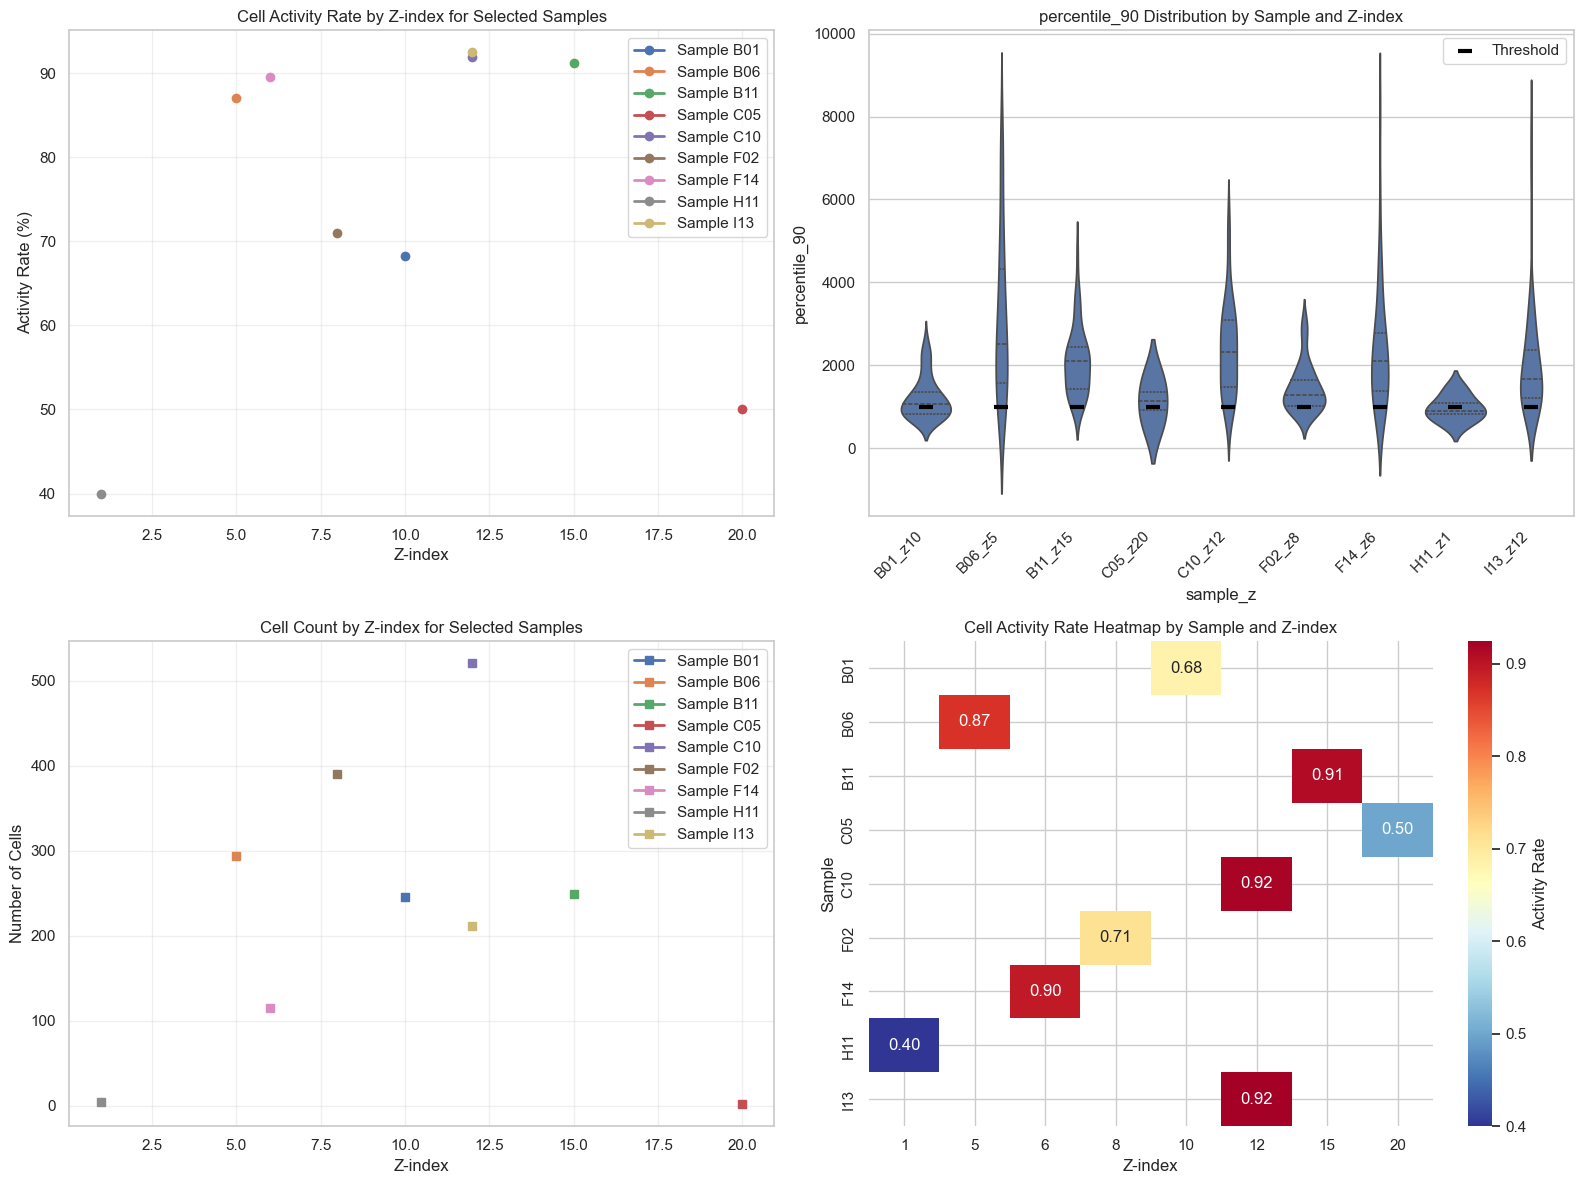


=== SAMPLE-WISE ANALYSIS SUMMARY ===

Sample B01:
  Z-index range: 10-10
  Total cells: 246
  Average activity rate: 68.3%
  Activity rate range: 68.3% - 68.3%

Sample B06:
  Z-index range: 5-5
  Total cells: 294
  Average activity rate: 87.1%
  Activity rate range: 87.1% - 87.1%

Sample B11:
  Z-index range: 15-15
  Total cells: 249
  Average activity rate: 91.2%
  Activity rate range: 91.2% - 91.2%

Sample C05:
  Z-index range: 20-20
  Total cells: 2
  Average activity rate: 50.0%
  Activity rate range: 50.0% - 50.0%

Sample C10:
  Z-index range: 12-12
  Total cells: 521
  Average activity rate: 91.9%
  Activity rate range: 91.9% - 91.9%

Sample F02:
  Z-index range: 8-8
  Total cells: 390
  Average activity rate: 71.0%
  Activity rate range: 71.0% - 71.0%

Sample F14:
  Z-index range: 6-6
  Total cells: 115
  Average activity rate: 89.6%
  Activity rate range: 89.6% - 89.6%

Sample H11:
  Z-index range: 1-1
  Total cells: 5
  Average activity rate: 40.0%
  Activity rate range: 40.0

In [ ]:
# plot_activity_variation(sample_data)


In [84]:
## Save results and export labels

In [ ]:
# , visualize_sample_zstack_napari
# Napari visualization functions




def _extract_z_index_from_image_name(image_name):
    """Extract z-index from image filename.
    
    Pattern: p2426_B02_z10_w2.tif -> z_index=10
    """
    import re
    if not isinstance(image_name, str):
        return None
    match = re.search(r'_z(\d+)_', image_name)
    if match:
        return int(match.group(1))
    match = re.search(r'_z(\d+)\.', image_name)
    if match:
        return int(match.group(1))
    return None


def _ensure_z_index_column(metrics_df):
    """Ensure metrics_df has a 'z_index' column, extracting from image names if needed."""
    if metrics_df is None or metrics_df.empty:
        return metrics_df
    
    if 'z_index' not in metrics_df.columns or metrics_df['z_index'].isna().all():
        metrics_df = metrics_df.copy()
        metrics_df['z_index'] = metrics_df['image'].apply(_extract_z_index_from_image_name)
    
    return metrics_df


In [ ]:
# Example usage: Visualize images and z-stacks
# Uncomment and modify the lines below to visualize specific images

# Example 1: Show a single image
# image_to_show = "p2426_B02_z15_w2.tif"  # Replace with actual image name
# viewer = visualize_image_with_napari(image_to_show, metrics_df, root)

# Example 2: Show complete z-stack for a sample (🆕 NEW!)
# sample_to_show = "B02"  # Replace with actual sample ID
# viewer = visualize_sample_zstack_napari(sample_to_show, metrics_df, root, max_z_slices=25)

# Example 3: Show multiple images from a sample in separate windows
# viewers = show_sample_images_napari("B02", z_indices=[10, 15, 20], max_images=3)

# Example 4: Browse available images and samples
def create_and_display_napari_viewer():

    print("📋 Available samples and images for visualization:")
    if 'metrics_df' in locals() and len(metrics_df) > 0:
        # Show sample summary with z-range information
        sample_info = metrics_df.groupby('sample').agg({
            'z_index': ['min', 'max', 'count', 'nunique'],
            'is_active': ['count', 'sum'],
            'image': 'nunique'
        }).round(1)
        
        print(f"\n🔬 Available samples ({len(sample_info)} total):")
        print("Sample | Z-range  | Z-slices | Total cells | Active cells | Images")
        print("-" * 70)
        
        for sample in sorted(sample_info.index)[:5]:  # Show first 5 samples
            z_min = int(sample_info.loc[sample, ('z_index', 'min')])
            z_max = int(sample_info.loc[sample, ('z_index', 'max')])
            z_count = int(sample_info.loc[sample, ('z_index', 'nunique')])
            total_cells = int(sample_info.loc[sample, ('is_active', 'count')])
            active_cells = int(sample_info.loc[sample, ('is_active', 'sum')])
            n_images = int(sample_info.loc[sample, ('image', 'nunique')])
            
            activity_rate = (active_cells / total_cells) * 100 if total_cells > 0 else 0
            
            print(f"{sample:>6} | {z_min:2d}-{z_max:2d}    | {z_count:8d} | {total_cells:11d} | "
                f"{active_cells:11d} ({activity_rate:4.1f}%) | {n_images:6d}")
        
        if len(sample_info) > 5:
            print(f"... and {len(sample_info) - 5} more samples")
        
        print(f"\n💡 Usage examples:")
        print(f"   # View single image")
        print(f"   viewer = visualize_image_with_napari('IMAGE_NAME', metrics_df, root)")
        print(f"   ")
        print(f"   # View complete z-stack in 3D (🆕 NEW!)")
        print(f"   viewer = visualize_sample_zstack_napari('SAMPLE_ID', metrics_df, root)")
        print(f"   ")
        print(f"   # View z-stack with limited slices for better performance")
        print(f"   viewer = visualize_sample_zstack_napari('SAMPLE_ID', metrics_df, root, max_z_slices=20)")

    else:
        print("   No data available. Please run the previous cells first.")

    print(f"\n🎛️ Advanced Z-Stack Usage:")
    print(f"   # Load specific sample with custom slice limit")
    print(f"   # viewer = visualize_sample_zstack_napari('B02', metrics_df, root, max_z_slices=15)")
    print(f"   ")
    print(f"   # Show only certain layers in the z-stack")
    print(f"   # viewer = visualize_sample_zstack_napari('C16', metrics_df, root, ")
    print(f"   #                                       show_original=True, show_labels=False, show_activity=True)")

    print(f"\n🎯 Z-Stack Features:")
    print(f"   • 📚 All z-slices from a sample loaded as 3D volume")
    print(f"   • 🎮 Interactive 3D navigation (scroll, rotate, zoom)")
    print(f"   • 📊 Combined statistics across all z-slices")
    print(f"   • 🎨 Layer-by-layer activity classification visualization")
    print(f"   • ⚡ Configurable slice limit for performance")
    print(f"   • 🧊 Automatic 3D view mode enabled")

    print(f"\n⚠️  Performance Tips:")
    print(f"   • For large datasets, limit z-slices (max_z_slices=20 or less)")
    print(f"   • Each z-stack viewer loads all slices into memory")
    print(f"   • Close previous viewers before opening new ones")
    print(f"   • Use the interactive widget interface for easier control")

📋 Available samples and images for visualization:

🔬 Available samples (16 total):
Sample | Z-range  | Z-slices | Total cells | Active cells | Images
----------------------------------------------------------------------
   B02 |  1-29    |       28 |        2035 |         535 (26.3%) |     28
   B04 |  1-27    |       27 |        4594 |        1104 (24.0%) |     27
   B05 |  1-25    |       25 |        4997 |        1184 (23.7%) |     25
   C01 |  1-27    |       27 |        3610 |         814 (22.5%) |     27
   C02 |  1-22    |       22 |        3622 |         851 (23.5%) |     22
... and 11 more samples

💡 Usage examples:
   # View single image
   viewer = visualize_image_with_napari('IMAGE_NAME', metrics_df, root)
   
   # View complete z-stack in 3D (🆕 NEW!)
   viewer = visualize_sample_zstack_napari('SAMPLE_ID', metrics_df, root)
   
   # View z-stack with limited slices for better performance
   viewer = visualize_sample_zstack_napari('SAMPLE_ID', metrics_df, root, max_z_slices